In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import binned_statistic

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'  
plt.rcParams['font.family'] = 'serif'

In [2]:
data = np.loadtxt('/Users/pablovazquez/GALA_hole/build/excitPos5_Xe4bar_100ev_grid.txt')

In [3]:
data = pd.DataFrame(data, columns=['event_id', 'x', 'y', 'z', 'time'])

In [4]:
data

,event_id,x,y,z,time
0,0.0,0.794892,0.468623,1.082590,4074.74
1,0.0,0.804224,0.454082,1.082060,4145.65
2,0.0,0.787108,0.371149,1.056060,4641.64
3,0.0,0.784974,0.366582,1.061450,4651.48
4,0.0,0.786341,0.359275,1.055250,4685.04
...,...,...,...,...,...
5078,99.0,-0.794590,0.089736,0.035380,6797.65
5079,99.0,-0.802186,0.084186,0.037222,6826.24
5080,99.0,-0.804413,0.081506,0.038314,6832.40
5081,99.0,-0.810161,0.072107,0.033310,6876.78


In [5]:
data

,event_id,x,y,z,time
0,0.0,0.794892,0.468623,1.082590,4074.74
1,0.0,0.804224,0.454082,1.082060,4145.65
2,0.0,0.787108,0.371149,1.056060,4641.64
3,0.0,0.784974,0.366582,1.061450,4651.48
4,0.0,0.786341,0.359275,1.055250,4685.04
...,...,...,...,...,...
5078,99.0,-0.794590,0.089736,0.035380,6797.65
5079,99.0,-0.802186,0.084186,0.037222,6826.24
5080,99.0,-0.804413,0.081506,0.038314,6832.40
5081,99.0,-0.810161,0.072107,0.033310,6876.78


In [6]:
exc = data.groupby('event_id').size()
normalized_exc = (exc / np.mean(exc.to_numpy())).to_numpy()

In [7]:
data['z'] = data['z'] - 0.5
data = data[(data.x > -0.25) & (data.x < 0.25) & (data.z > -0.25) & (data.z < 0.25)]

In [8]:
mean_x = data.groupby('event_id')['x'].mean()
mean_z = data.groupby('event_id')['z'].mean() 
event_length = data.groupby('event_id')
event_times = data.groupby('event_id')['time'].max() -  data.groupby('event_id')['time'].min()

In [9]:
mean_R = mean_x.to_numpy()**2 + mean_z.to_numpy()**2


0.07355030405562805

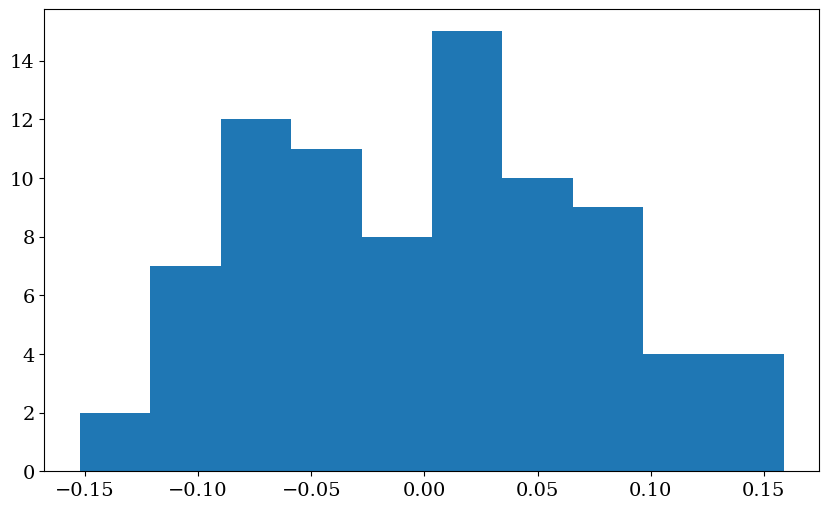

In [10]:
plt.hist(mean_x)
np.std(mean_x)

Eventos analizados: 82
Pearson r = 0.601, p = 2.436e-09
Spearman rho = 0.589, p = 5.660e-09
Pearson (radius vs path length) r = 0.443, p = 3.023e-05
Spearman (radius vs path length) rho = 0.444, p = 2.952e-05


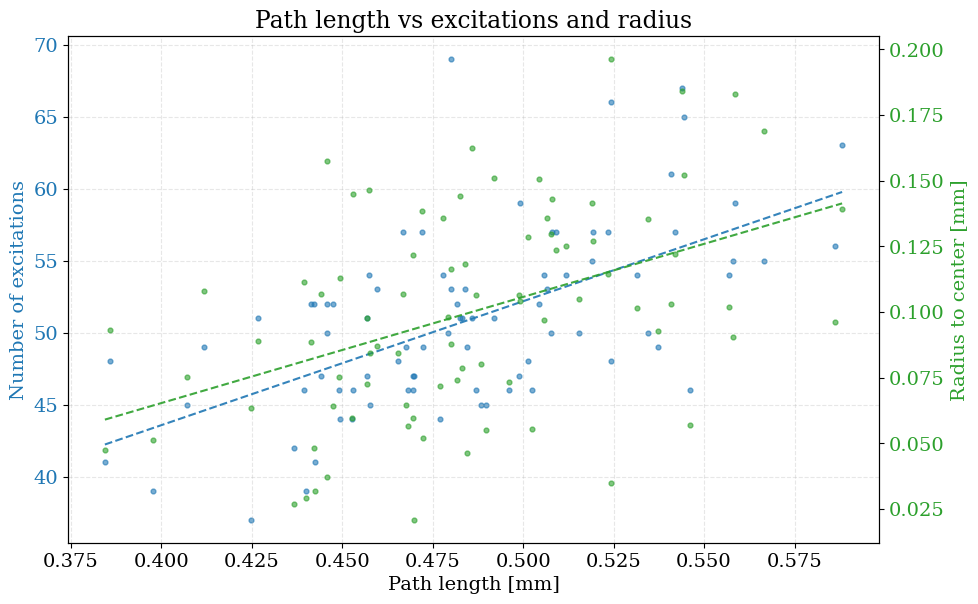


Primeras filas de `events`:
   event_id  path_length_mm  n_excitations  duration_ns  radius_mm  exc_per_mm
0       4.0        0.588149             63      1857.91   0.139105  107.115760
1       5.0        0.465321             48      1600.32   0.084263  103.154666
2      11.0        0.469900             47      1570.50   0.020922  100.021236
3      12.0        0.556890             54      1897.77   0.101955   96.967051
4      13.0        0.541963             57      1802.81   0.121909  105.173276


In [11]:
# Calcular longitud de camino por evento y analizar correlación con número de excitaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# función que calcula la longitud de camino (mm) para un grupo de hits ordenados por tiempo
def path_length_for_group(g):
    coords = g.sort_values('time')[['x','y','z']].to_numpy()
    if coords.shape[0] < 2:
        return 0.0
    diffs = np.linalg.norm(np.diff(coords, axis=0), axis=1)
    return float(diffs.sum())

# calcular longitud por evento
event_length = data.groupby('event_id').apply(path_length_for_group)

# número de excitaciones por evento
exc_series = data.groupby('event_id').size()

# duración del evento (ns)
event_duration = data.groupby('event_id')['time'].agg(lambda s: s.max() - s.min())

# radio medio por evento (distancia al centro en el plano x-z)
mean_x = data.groupby('event_id')['x'].mean()
mean_z = data.groupby('event_id')['z'].mean()
radius_series = np.sqrt(
    mean_x.reindex(event_length.index).to_numpy()**2 +
    mean_z.reindex(event_length.index).to_numpy()**2
)

# Construir DataFrame con resultados
events = pd.DataFrame({
    'event_id': event_length.index,
    'path_length_mm': event_length.values,
    'n_excitations': exc_series.reindex(event_length.index).fillna(0).astype(int).values,
    'duration_ns': event_duration.reindex(event_length.index).fillna(0).values,
    'radius_mm': radius_series,
})

# Correlaciones path length vs excitaciones
mask = (events['path_length_mm'] > 0) & np.isfinite(events['n_excitations'])
if mask.sum() >= 2:
    r_p, p_p = pearsonr(events.loc[mask, 'path_length_mm'], events.loc[mask, 'n_excitations'])
    r_s, p_s = spearmanr(events.loc[mask, 'path_length_mm'], events.loc[mask, 'n_excitations'])
else:
    r_p = r_s = p_p = p_s = np.nan

print(f"Eventos analizados: {len(events):,}")
print(f"Pearson r = {r_p:.3f}, p = {p_p:.3e}")
print(f"Spearman rho = {r_s:.3f}, p = {p_s:.3e}")

# Correlación radius vs path length
mask_r = np.isfinite(events['radius_mm']) & np.isfinite(events['path_length_mm'])
if mask_r.sum() >= 2:
    r_pr, p_pr = pearsonr(events.loc[mask_r, 'radius_mm'], events.loc[mask_r, 'path_length_mm'])
    r_sr, p_sr = spearmanr(events.loc[mask_r, 'radius_mm'], events.loc[mask_r, 'path_length_mm'])
else:
    r_pr = r_sr = p_pr = p_sr = np.nan

print(f"Pearson (radius vs path length) r = {r_pr:.3f}, p = {p_pr:.3e}")
print(f"Spearman (radius vs path length) rho = {r_sr:.3f}, p = {p_sr:.3e}")

# Gráfico combinado: X = path length, Y izquierdo = excitaciones, Y derecho = radio medio
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.scatter(events['path_length_mm'], events['n_excitations'], s=12, alpha=0.6, color=color1, label='Number of excitations')
ax1.set_xlabel('Path length [mm]')
ax1.set_ylabel('Number of excitations', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(alpha=0.3, linestyle='--')

if mask.sum() >= 2:
    m1, b1 = np.polyfit(events.loc[mask, 'path_length_mm'], events.loc[mask, 'n_excitations'], 1)
    xs1 = np.linspace(events['path_length_mm'].min(), events['path_length_mm'].max(), 200)
    ax1.plot(xs1, m1 * xs1 + b1, color=color1, linestyle='--', alpha=0.9)

ax2 = ax1.twinx()
color2 = 'tab:green'
ax2.scatter(events['path_length_mm'], events['radius_mm'], s=12, alpha=0.6, color=color2, label='Radius to center')
ax2.set_ylabel('Radius to center [mm]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

if mask_r.sum() >= 2:
    m2, b2 = np.polyfit(events.loc[mask_r, 'path_length_mm'], events.loc[mask_r, 'radius_mm'], 1)
    xs2 = np.linspace(events['path_length_mm'].min(), events['path_length_mm'].max(), 200)
    ax2.plot(xs2, m2 * xs2 + b2, color=color2, linestyle='--', alpha=0.9)

fig.tight_layout()
plt.title('Path length vs excitations and radius')
plt.show()

# Añadir columnas al dataframe 'events' y mostrar un resumen
events['exc_per_mm'] = events['n_excitations'] / events['path_length_mm'].replace(0, np.nan)
print('\nPrimeras filas de `events`:')
print(events.head())


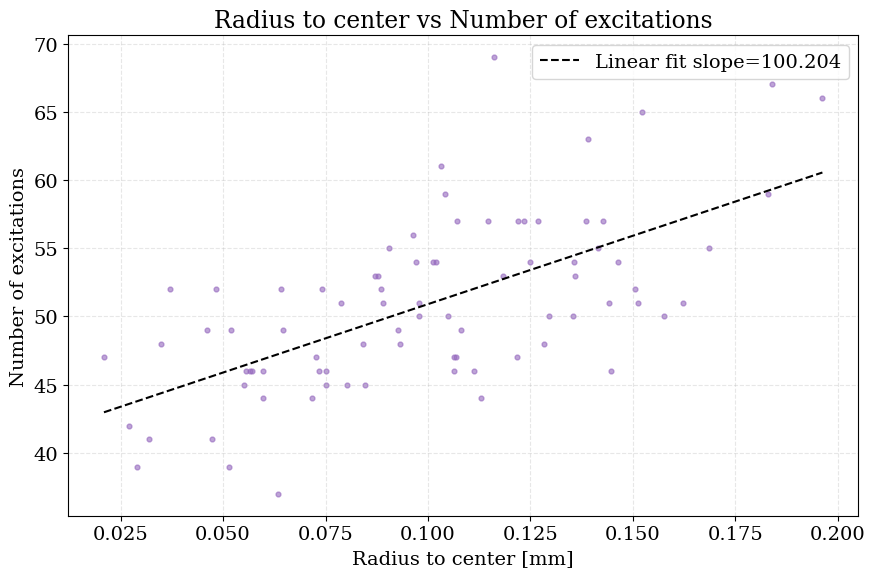

In [12]:
# Plot: radius to center vs number of excitations
plt.figure(figsize=(9, 6))
plt.scatter(events['radius_mm'], events['n_excitations'], s=12, alpha=0.6, color='tab:purple')

mask_radius = np.isfinite(events['radius_mm']) & np.isfinite(events['n_excitations'])
if mask_radius.sum() >= 2:
    m_r, b_r = np.polyfit(events.loc[mask_radius, 'radius_mm'], events.loc[mask_radius, 'n_excitations'], 1)
    xs_r = np.linspace(events['radius_mm'].min(), events['radius_mm'].max(), 200)
    plt.plot(xs_r, m_r * xs_r + b_r, 'k--', label=f'Linear fit slope={m_r:.3f}')
    plt.legend()

plt.xlabel('Radius to center [mm]')
plt.ylabel('Number of excitations')
plt.title('Radius to center vs Number of excitations')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


In [13]:
radius = np.sqrt(mean_x.to_numpy()**2 + mean_z.to_numpy()**2)

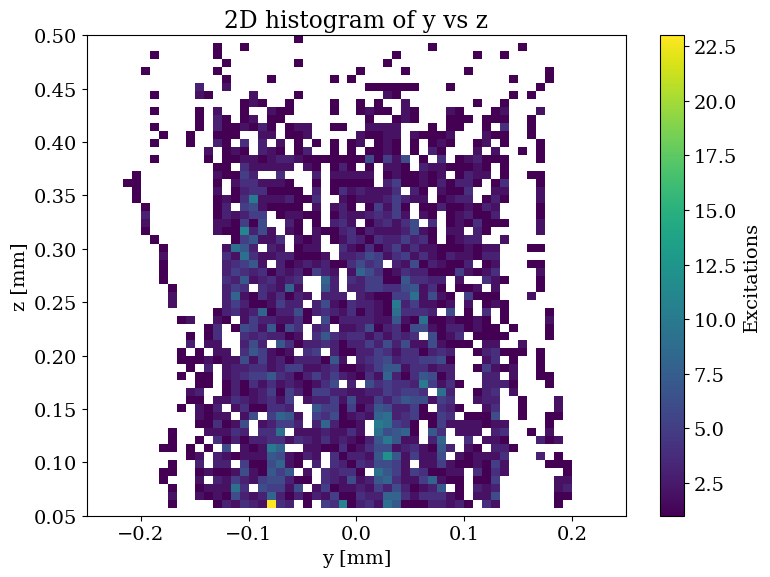

In [14]:
plt.figure(figsize=(8, 6))
plt.hist2d(
    data['z'],
    data['y'],
    bins=60,
    range=[(-0.25, 0.25), (0.05, 0.5)],
    cmap='viridis',
    cmin = 1
)
plt.colorbar(label='Excitations')
plt.xlabel('y [mm]')
plt.ylabel('z [mm]')
plt.title('2D histogram of y vs z')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'z [mm]')

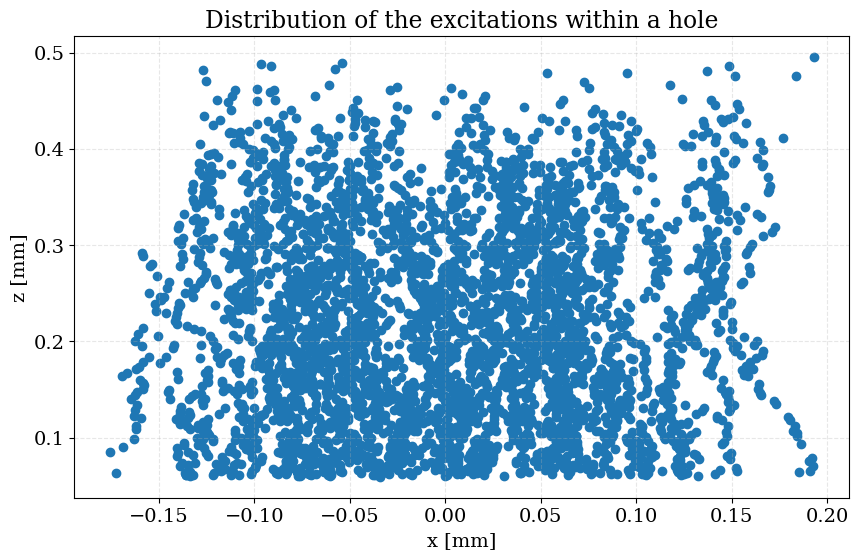

In [15]:
plt.scatter(
    data['x'],
    data['y']
)
plt.grid(True, alpha = 0.3, linestyle = '--')
plt.title('Distribution of the excitations within a hole')
plt.xlabel('x [mm]')
plt.ylabel('z [mm]')

Text(0, 0.5, 'z [mm]')

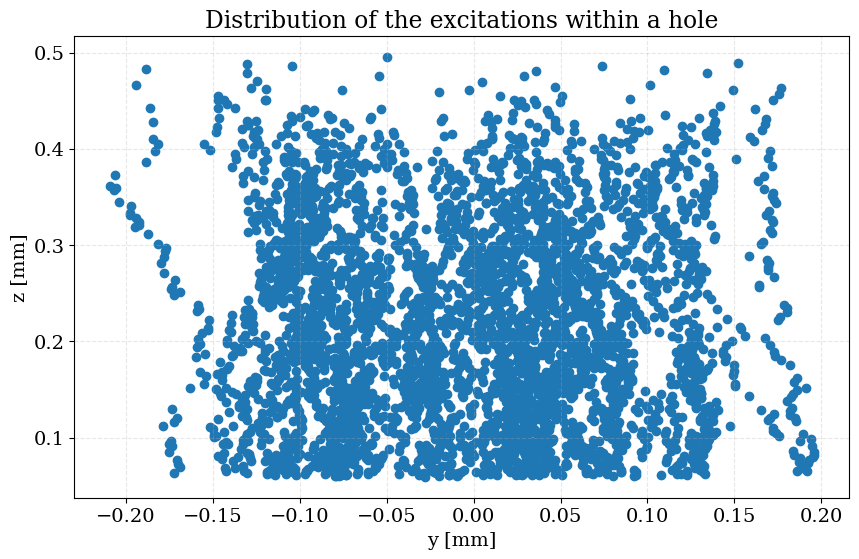

In [16]:
plt.scatter(
    data['z'],
    data['y']
)
plt.grid(True, alpha = 0.3, linestyle = '--')
plt.title('Distribution of the excitations within a hole')
plt.xlabel('y [mm]')
plt.ylabel('z [mm]')

<function matplotlib.pyplot.axvline(x=0, ymin=0, ymax=1, **kwargs)>

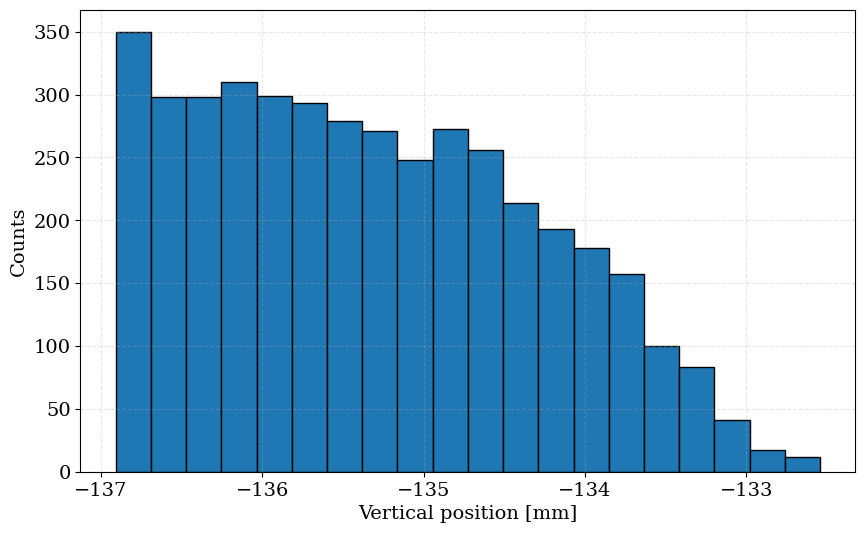

In [27]:
plt.hist(data['y']*10-137.5, bins = 20, edgecolor = 'black')
plt.ylabel('Counts')
plt.xlabel('Vertical position [mm]')
plt.grid(True, alpha = 0.3, linestyle = '--')
plt.axvline

In [28]:
counts, bins = np.histogram(data['y']*10-137.5, bins = 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

In [29]:
bin_centers

array([-136.79840302, -136.58019108, -136.36197913, -136.14376717,
       -135.92555523, -135.70734327, -135.48913133, -135.27091938,
       -135.05270742, -134.83449548, -134.61628353, -134.39807158,
       -134.17985963, -133.96164767, -133.74343573, -133.52522378,
       -133.30701183, -133.08879988, -132.87058792, -132.65237598])

Text(0.5, 0, 'Z position')

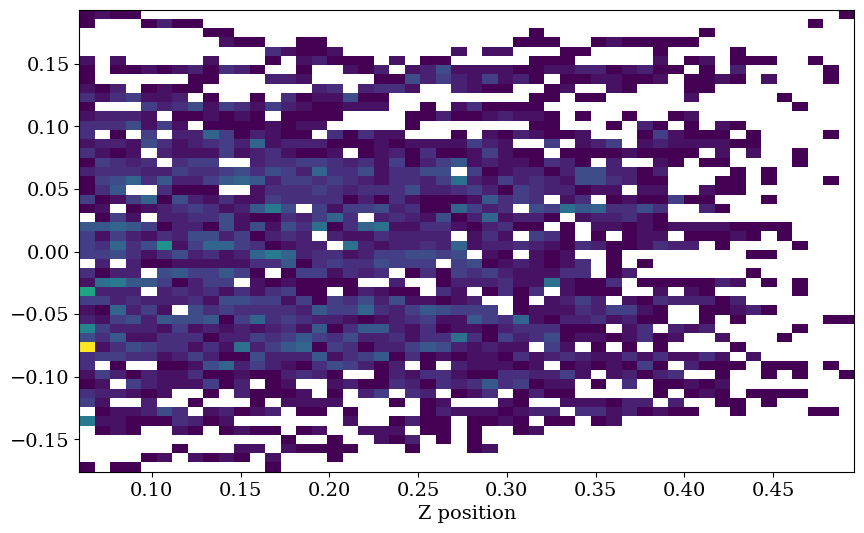

In [20]:
plt.hist2d(data['y'], data['x'] , bins = 50, cmin = 1)
plt.xlabel('Z position')

<function matplotlib.pyplot.axvline(x=0, ymin=0, ymax=1, **kwargs)>

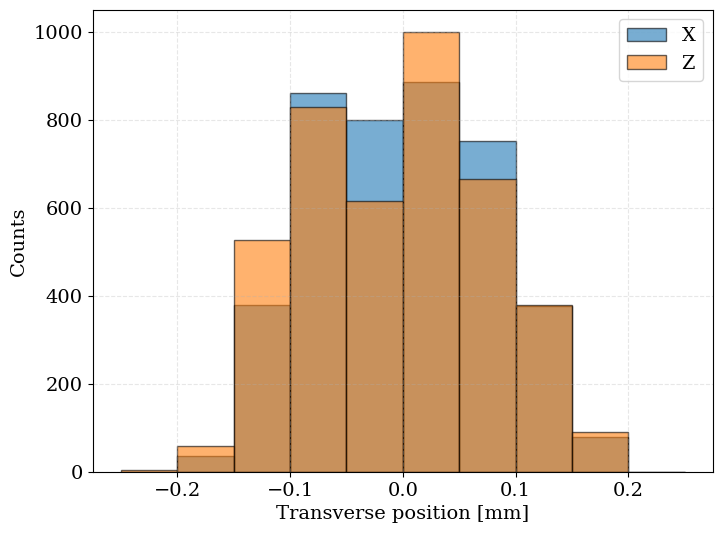

In [21]:
plt.figure(figsize = (8, 6))
plt.hist(data['x'], bins = 10, edgecolor = 'black', alpha = 0.6, range = (-0.25, 0.25), label = 'X')
plt.hist(data['z'], bins = 10, edgecolor = 'black', alpha = 0.6, range = (-0.25, 0.25), label = 'Z')
plt.xlabel('Transverse position [mm]')
plt.ylabel('Counts')
plt.grid('True');
plt.grid(True, alpha = 0.3, linestyle = '--');
plt.legend();
plt.axvline

Integral sin normalizar: 1080.683843892532195
f_max (normalizada): 0.281481148301732


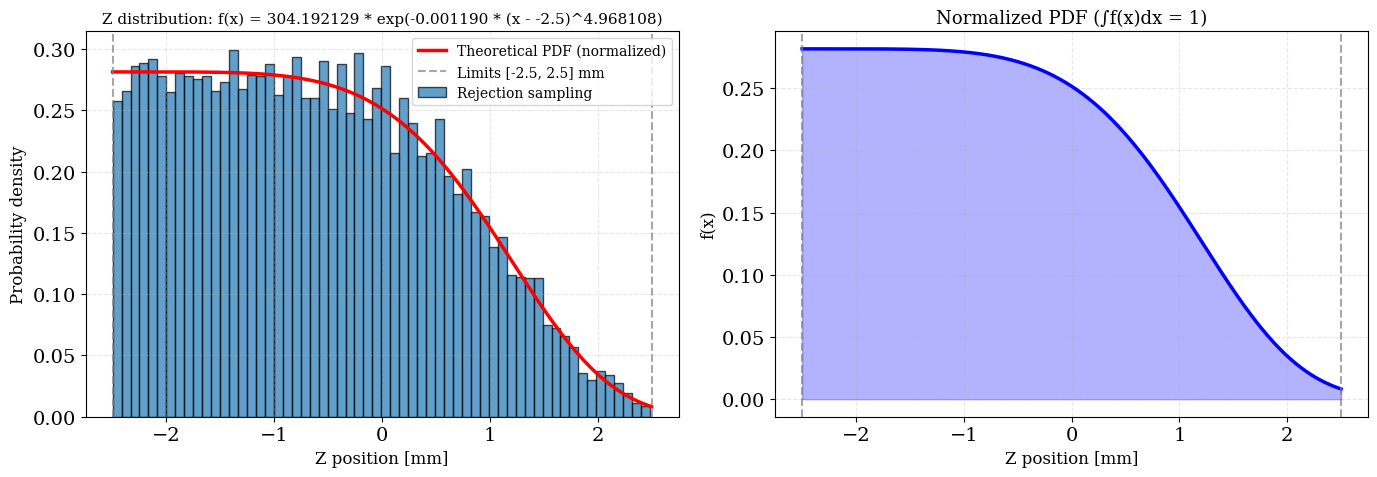


=== MUESTREO POR REJECTION SAMPLING ===
Generadas 10,000 muestras de Z
Muestras dentro de [-2.5, 2.5]: 10,000 (100.0%)
Media de X: -0.618527 mm
Desviación estándar: 1.160229 mm
Rango: [-2.499942, 2.486189] mm
Percentiles: 25%=-1.598213, 50%=-0.694826, 75%=0.252965

=== VALIDACIÓN DE NORMALIZACIÓN ===
Integral numérica de PDF normalizada: 1.000000000000000 (debe ser ≈ 1.0)
Integral sin normalizar: 1080.683843892532195
Máximo de PDF normalizada: 0.281481148301732
Mínimo de PDF normalizada (> 0): 0.008226637361702

=== PARÁMETROS ===
Fórmula: f(x) = A * exp(-λ * (x - x_min)^n)
Parámetros: A=304.19212933000, λ=0.00119000000, n=4.96810781000
Rango: [-2.5, 2.5] mm (asimétrica con shift)

Para C++: integral_unnormalized = 1080.683843892532195


In [22]:
# Generar posiciones Z con distribución: f(x) = A * exp(-λ * (x - x_min)^n) en rango [-0.25, 0.25] mm
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Parámetros: rango [-0.25, 0.25] mm (asimétrica con shift)
x_min = -2.5
x_max = 2.5

# Parámetros de la distribución (nuevos valores)
A_fit = 304.19212933
lambda_fit = 0.00119
n_fit = 4.96810781

def pdf_x_unnormalized(x):
    """
    Distribución asimétrica con shift: f(x) = A * exp(-λ * (x - x_min)^n)
    Para x en [-0.25, 0.25] mm
    Máximo en x=x_min donde f(x_min) = A
    Decae hacia x_max (asimétrica, no simétrica)
    """
    if x_min <= x <= x_max:
        return A_fit * np.exp(-lambda_fit * np.power(x - x_min, n_fit))
    else:
        return 0.0

# Vectorizar
pdf_x_unnormalized_vec = np.vectorize(pdf_x_unnormalized)

# Normalizar: calcular integral y dividir para que área = 1
integral_unnormalized, _ = quad(pdf_x_unnormalized, x_min, x_max)
print(f'Integral sin normalizar: {integral_unnormalized:.15f}')

def pdf_x_normalized(x):
    """Distribución normalizada (área bajo la curva = 1)"""
    return pdf_x_unnormalized(x) / integral_unnormalized

pdf_x_normalized_vec = np.vectorize(pdf_x_normalized)

# Muestreo por rejection sampling
N_samples = 10000
x_samples = []

# Máximo de la función normalizada en el rango [-0.25, 0.25]
x_test = np.linspace(x_min, x_max, 1000)
pdf_test = pdf_x_normalized_vec(x_test)
f_max_normalized = np.max(pdf_test)
print(f'f_max (normalizada): {f_max_normalized:.15f}')

np.random.seed(42)
while len(x_samples) < N_samples:
    x_candidate = x_min + np.random.uniform() * (x_max - x_min)
    fx = pdf_x_normalized(x_candidate)
    
    if np.random.uniform() < fx / f_max_normalized:
        x_samples.append(x_candidate)

x_samples = np.array(x_samples)

# Graficar histograma de muestras generadas vs función teórica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de muestras (normalizado)
ax1.hist(x_samples, bins=60, density=True, alpha=0.7, edgecolor='black', label='Rejection sampling')

# Función teórica normalizada
x_theory = np.linspace(x_min, x_max, 500)
pdf_theory = pdf_x_normalized_vec(x_theory)
ax1.plot(x_theory, pdf_theory, 'r-', linewidth=2.5, label='Theoretical PDF (normalized)')

ax1.axvline(x_min, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Limits [{x_min}, {x_max}] mm')
ax1.axvline(x_max, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Z position [mm]', fontsize=12)
ax1.set_ylabel('Probability density', fontsize=12)
ax1.set_title(f'Z distribution: f(x) = {A_fit:.6f} * exp(-{lambda_fit:.6f} * (x - {x_min})^{n_fit:.6f})', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Gráfico 2: función normalizada (área bajo la curva = 1)
ax2.plot(x_theory, pdf_theory, 'b-', linewidth=2.5)
ax2.fill_between(x_theory, 0, pdf_theory, alpha=0.3, color='blue')
ax2.axvline(x_min, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(x_max, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Z position [mm]', fontsize=12)
ax2.set_ylabel('f(x)', fontsize=12)
ax2.set_title('Normalized PDF (∫f(x)dx = 1)', fontsize=13)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Estadísticas y validación
within_range = (x_samples >= x_min) & (x_samples <= x_max)
integral_normalized_check = quad(pdf_x_normalized, x_min, x_max)[0]

print(f'\n=== MUESTREO POR REJECTION SAMPLING ===')
print(f'Generadas {len(x_samples):,} muestras de Z')
print(f'Muestras dentro de [{x_min}, {x_max}]: {within_range.sum():,} ({within_range.sum()/len(x_samples)*100:.1f}%)')
print(f'Media de X: {np.mean(x_samples):.6f} mm')
print(f'Desviación estándar: {np.std(x_samples):.6f} mm')
print(f'Rango: [{np.min(x_samples):.6f}, {np.max(x_samples):.6f}] mm')
print(f'Percentiles: 25%={np.percentile(x_samples, 25):.6f}, 50%={np.percentile(x_samples, 50):.6f}, 75%={np.percentile(x_samples, 75):.6f}')

print(f'\n=== VALIDACIÓN DE NORMALIZACIÓN ===')
print(f'Integral numérica de PDF normalizada: {integral_normalized_check:.15f} (debe ser ≈ 1.0)')
print(f'Integral sin normalizar: {integral_unnormalized:.15f}')
print(f'Máximo de PDF normalizada: {np.max(pdf_theory):.15f}')
print(f'Mínimo de PDF normalizada (> 0): {np.min(pdf_theory[pdf_theory > 1e-10]):.15f}')

print(f'\n=== PARÁMETROS ===')
print(f'Fórmula: f(x) = A * exp(-λ * (x - x_min)^n)')
print(f'Parámetros: A={A_fit:.11f}, λ={lambda_fit:.11f}, n={n_fit:.11f}')
print(f'Rango: [{x_min}, {x_max}] mm (asimétrica con shift)')
print(f'\nPara C++: integral_unnormalized = {integral_unnormalized:.15f}')
